In [1]:
!pip install mp-api pandas scikit-learn matplotlib

In [2]:
from mp_api.client import MPRester
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
api_key = "imtT1ugxAvLr43DL0aH13q1ZGeSKSVGQ"

In [4]:
with MPRester(api_key) as m:
    docs = m.materials.summary.search(
        elements=["Li"],
        fields=[
            "formula_pretty",
            "band_gap",
            "formation_energy_per_atom",
            "energy_above_hull"
        ]
    )

rows = []
for d in docs:
    rows.append({
        "formula_pretty": d.formula_pretty,
        "band_gap": d.band_gap,
        "formation_energy_per_atom": d.formation_energy_per_atom,
        "energy_above_hull": d.energy_above_hull
    })

df = pd.DataFrame(rows)

print(df.head())
print("Total rows:", len(df))

Retrieving SummaryDoc documents:   0%|          | 0/21764 [00:00<?, ?it/s]

  formula_pretty  band_gap  formation_energy_per_atom  energy_above_hull
0             Li       0.0                   0.000000           0.000000
1             Li       0.0                   0.015671           0.015671
2             Li       0.0                   0.005988           0.005988
3             Li       0.0                   0.005889           0.005889
4             Li       0.0                   0.261799           0.261799
Total rows: 21764


In [5]:
df = df.dropna()

print("Rows after cleaning:", len(df))
print(df.head())

Rows after cleaning: 21764
  formula_pretty  band_gap  formation_energy_per_atom  energy_above_hull
0             Li       0.0                   0.000000           0.000000
1             Li       0.0                   0.015671           0.015671
2             Li       0.0                   0.005988           0.005988
3             Li       0.0                   0.005889           0.005889
4             Li       0.0                   0.261799           0.261799


In [6]:
df.to_csv("battery_materials_data.csv", index=False)
print("Dataset saved successfully")

Dataset saved successfully


In [7]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21764 entries, 0 to 21763
Data columns (total 4 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   formula_pretty             21764 non-null  object 
 1   band_gap                   21764 non-null  float64
 2   formation_energy_per_atom  21764 non-null  float64
 3   energy_above_hull          21764 non-null  float64
dtypes: float64(3), object(1)
memory usage: 680.3+ KB
None
           band_gap  formation_energy_per_atom  energy_above_hull
count  21764.000000               21764.000000       21764.000000
mean       1.282945                  -1.972647           0.136564
std        1.477749                   0.909005           0.414778
min        0.000000                  -4.095328           0.000000
25%        0.000000                  -2.541106           0.025657
50%        0.738400                  -2.206668           0.060032
75%        2.220475                

In [8]:
X = df[["band_gap", "formation_energy_per_atom"]]
y = df["energy_above_hull"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   band_gap  formation_energy_per_atom
0       0.0                   0.000000
1       0.0                   0.015671
2       0.0                   0.005988
3       0.0                   0.005889
4       0.0                   0.261799

Target:
0    0.000000
1    0.015671
2    0.005988
3    0.005889
4    0.261799
Name: energy_above_hull, dtype: float64


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 17411
Testing samples: 4353


In [10]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

print("Random Forest model trained successfully")

Random Forest model trained successfully


In [11]:
y_pred = model.predict(X_test)

print("First 10 predictions:")
print(y_pred[:10])

First 10 predictions:
[0.03320817 0.04193699 0.0232732  0.37393928 0.09433557 0.08352512
 0.04828718 0.03071151 0.08606345 0.12338451]


In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Absolute Error: 0.09657044530404668
Mean Squared Error: 0.07886037482585583
R2 Score: 0.626794684026277


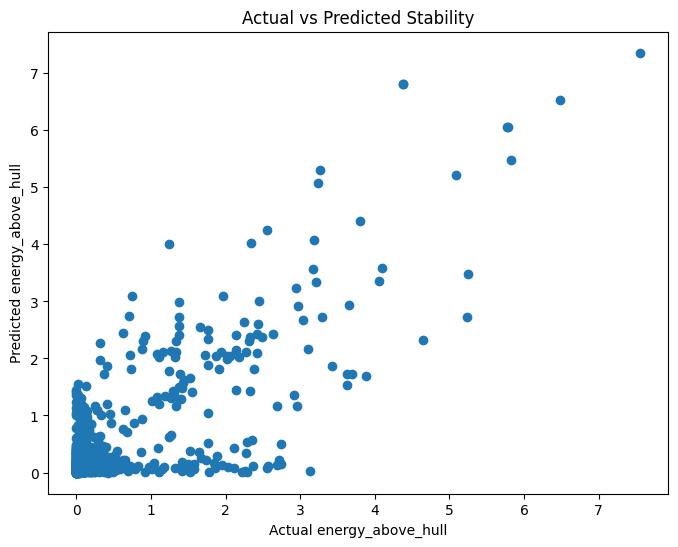

In [13]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual energy_above_hull")
plt.ylabel("Predicted energy_above_hull")
plt.title("Actual vs Predicted Stability")
plt.show()

In [14]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

print(feature_importance)

                     Feature  Importance
0                   band_gap    0.056409
1  formation_energy_per_atom    0.943591


In [15]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Linear Regression model trained successfully")

Linear Regression model trained successfully


In [16]:
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression R2:", r2_lr)
print("Random Forest R2:", r2)

Linear Regression R2: 0.3285731257437132
Random Forest R2: 0.626794684026277


In [17]:
if r2 > r2_lr:
    print("Random Forest performed better than Linear Regression.")
else:
    print("Linear Regression performed better than Random Forest.")

Random Forest performed better than Linear Regression.
